# AI Research Agent — Colab project

In this notebook you build a research pipeline with three stages: a
**researcher** that gathers facts with web tools, an **analyst** that
interprets the findings, and a **writer** that produces the final report.
You build the agents yourself with LangChain's `create_agent`, and you
chain them into a workflow yourself with LangGraph's Graph API
(`StateGraph`). The tools, the tracing helpers, and the shared runner are
given to you — you only write the parts marked TODO. There are three
TODOs: write the prompts (TODO #1), build the three agents (TODO #2),
and build the pipeline (TODO #3).

**Google Colab (easiest):** open this notebook in Colab, add a secret
named `OPENROUTER_API_KEY` (the key icon in the left sidebar, or
`Runtime → Edit session secrets`), then run the cells top to bottom
(`Runtime → Run all`) after you finish the TODOs.

**On your own machine:** run `uv sync` in this folder, then
`uv run jupyter lab research_agent.ipynb`, and put your key in a `.env`
file (copy `.env.example`).

In [1]:
# On your own machine (not Colab) run: uv sync — and skip this cell
!pip install -q "langchain>=1.4" "langgraph>=1.2.11" "langchain-openai>=1.2" beautifulsoup4 requests python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 7.8 MB/s eta 0:00:00


---

# Multi-Agent Deep Research System


## Project Description

This project builds a **multi-agent deep research system** using LangChain and LangGraph. It accepts a complex research question, creates a focused research plan, searches the web from different perspectives, evaluates the collected evidence, and produces an evidence-based final report.

The demonstration use case investigates the following question:

> **Should Saudi universities introduce an AI academic-advising assistant to help students with course selection, degree requirements, and university services?**

The system investigates potential educational benefits, implementation feasibility, information accuracy, student privacy, fairness, accessibility, human oversight, and relevant Saudi regulations. It uses only publicly available information and does not access real student records.

Unlike a simple sequential pipeline, the system runs two specialized research agents in parallel:

1. **Opportunity Researcher**

   * Searches for educational benefits, successful implementations, measurable outcomes, and evidence of technical feasibility.

2. **Risk Researcher**

   * Searches for risks, limitations, unsuccessful implementations, and evidence that may challenge the proposed idea.

After both researchers complete their work, the **Research Analyst** combines and analyzes their findings. The analyst identifies agreements, contradictions, assumptions, and areas of uncertainty.

The **Quality Checker** then determines whether the collected evidence is reliable and sufficient. If important evidence is missing, the workflow returns to the Research Planner for another targeted research round. If the evidence is sufficient, the **Report Writer** produces the final evidence-based report.

## Architecture
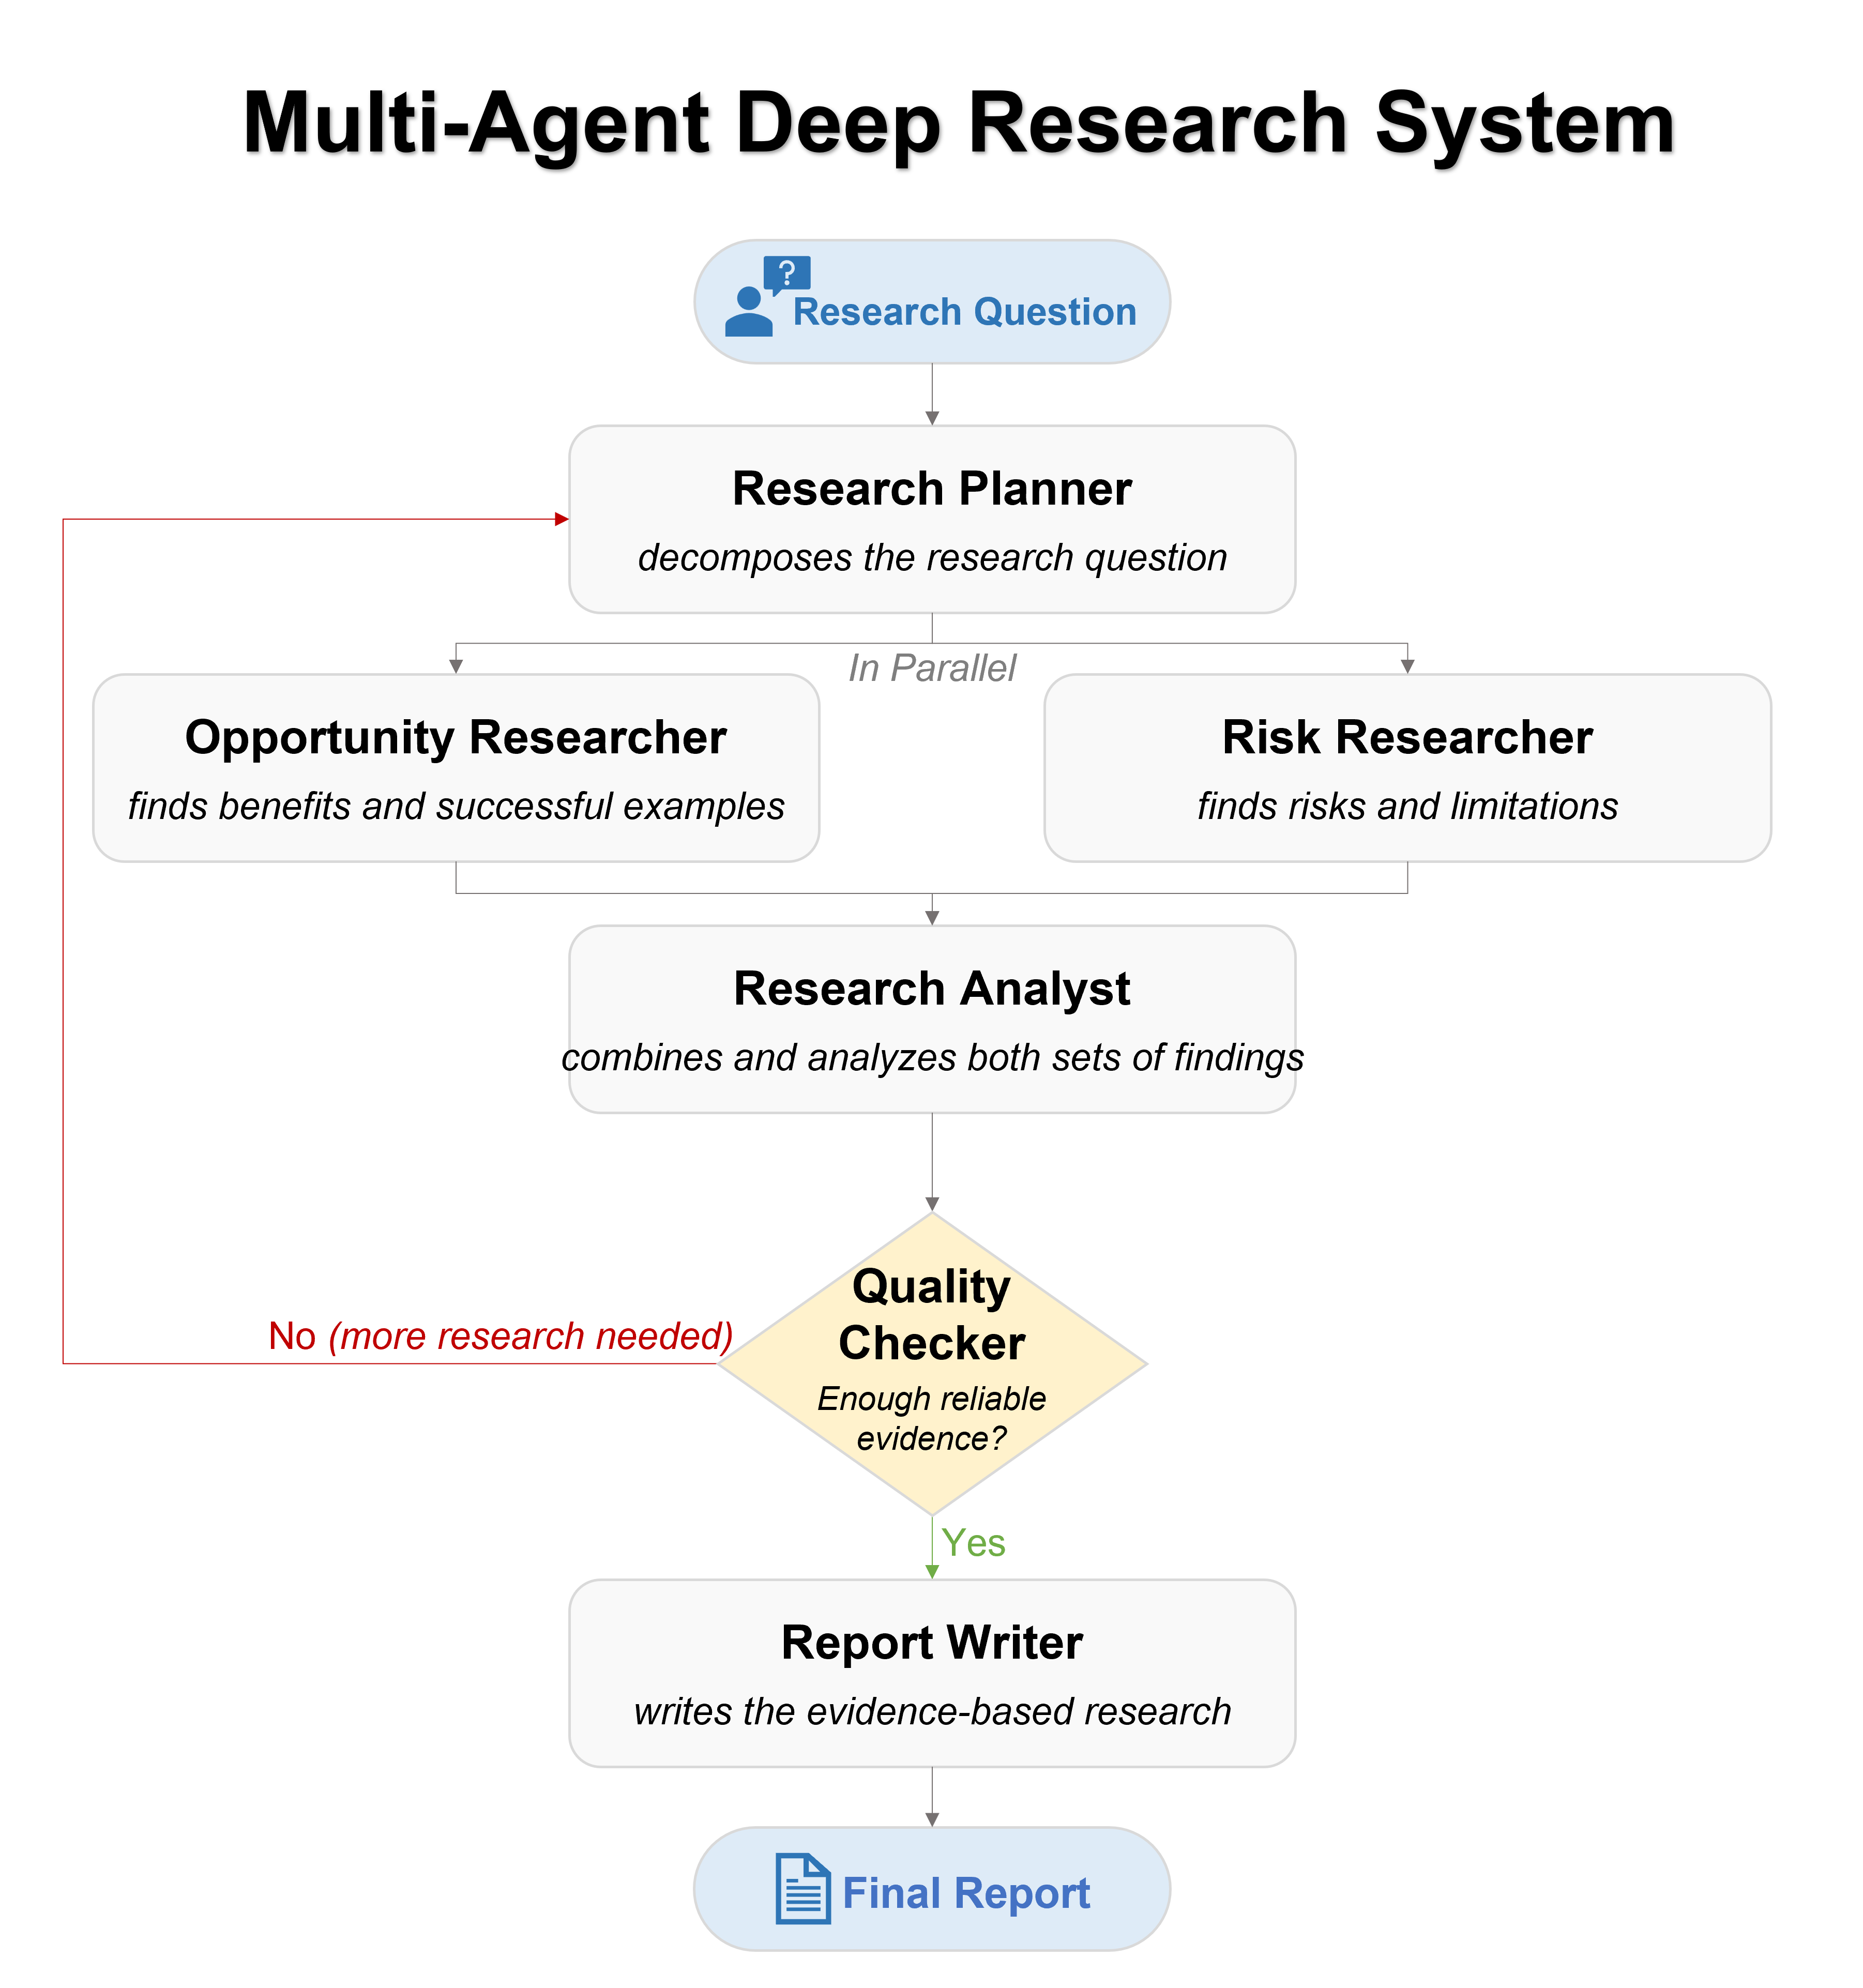

## Agent Responsibilities

| Agent                  | Responsibility                                                                                                        |
| ---------------------- | --------------------------------------------------------------------------------------------------------------------- |
| Research Planner       | Breaks the main question into focused research questions and updates the plan when more evidence is needed            |
| Opportunity Researcher | Searches for benefits, opportunities, successful examples, and supporting evidence.      |
| Risk Researcher        | Searches for risks, limitations, failed examples, and counter-evidence.                                 |
| Research Analyst       | Combines and analyzes both sets of findings and highlights agreements, contradictions, assumptions, and uncertainties |
| Quality Checker        | Determines whether the evidence is reliable and sufficient before the report is written                               |
| Report Writer          | Produces the final report using the approved evidence and analysis                                                    |

## Workflow

The system follows these steps:

1. The **Research Planner** divides the main question into smaller research questions.
2. The **Opportunity Researcher** and **Risk Researcher** conduct their research in parallel.
3. The **Research Analyst** combines and compares the findings from both researchers.
4. The **Quality Checker** evaluates whether the evidence is sufficient and reliable.
5. If more evidence is needed, the workflow returns to the Research Planner with a specific research gap.
6. If the evidence is sufficient, the **Report Writer** creates the final report.
7. The workflow ends after producing the evidence-based final report.

## Why This Architecture?

This architecture was selected for the following reasons:

1. **Parallel research:**
   The Opportunity Researcher and Risk Researcher work at the same time. This reduces execution time compared with running both research tasks sequentially.

2. **Balanced perspectives:**
   Separating opportunity research from risk research reduces one-sided analysis and confirmation bias. The system actively searches for both supporting and opposing evidence.

3. **Clear agent responsibilities:**
   Each agent performs one focused task: planning, researching, analyzing, checking evidence, or writing. This makes the workflow easier to understand, test, and improve.

4. **Evidence analysis before evaluation:**
   The Research Analyst combines the two research outputs before the Quality Checker evaluates them. This allows the checker to examine one organized evidence package instead of disconnected research notes.

5. **Evidence checking before writing:**
   The Report Writer is called only after the evidence is considered sufficient. This avoids spending time and model calls writing a report that would immediately require additional research.

6. **Targeted research loop:**
   If evidence is missing, the Quality Checker identifies a specific gap and sends it back to the Research Planner. The next research round focuses on resolving that gap instead of repeating the entire process without direction.

7. **Bounded execution:**
   The research loop has a maximum number of rounds. Tool-call limits, source checks, loop detection, execution tracing, and checkpointing are also used to improve reliability and prevent uncontrolled execution.

## Expected Final Report

The final report should include:

* An executive summary of the main findings.
* A clear response to the original research question.
* The strongest supporting evidence and opportunities.
* Relevant risks, limitations, and counter-evidence.
* A comparison of different perspectives and findings.
* Evidence from credible and publicly available sources.
* Relevant legal, regulatory, ethical, or contextual considerations when applicable.
* Areas where the available evidence is uncertain, limited, or conflicting.
* A balanced conclusion or recommendation when requested by the research question.
* Practical next steps when appropriate.
* A list of the sources used.


## References

The implementation and architecture are based on the following course materials, official documentation, and research:

* Course lab: `multi_agent_newsroom.ipynb` — shared state, parallel specialist agents, evidence synthesis, and conditional routing.
* Course lab: `flow_engineering.ipynb` — typed state, bounded loops, routing rules, and checkpointing.
* [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents) — parallelization, routing, orchestrator-worker, and evaluator-optimizer patterns.
* [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents) — agent creation and tool-calling loops.
* [STORM: Synthesis of Topic Outlines through Retrieval and Multi-Perspective Question Asking](https://arxiv.org/abs/2402.14207) — using diverse research perspectives before producing long-form content.
* [Improving Factuality and Reasoning through Multi-Agent Debate](https://arxiv.org/abs/2305.14325) — using independent agents and reconciliation to improve factuality.
* [Self-Refine: Iterative Refinement with Self-Feedback](https://arxiv.org/abs/2303.17651) — improving outputs through feedback and bounded iterative refinement.
---

## 1. Setup

This cell is complete — just run it. It reads your API key (from Colab
Secrets, from `.env`, or by asking you) and creates `llm`, the model
object every agent in this notebook will use.

In [2]:
import getpass
import os
from typing import TypedDict

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

try:
    # Running in Google Colab? Read the key from Colab Secrets.
    from google.colab import userdata
    try:
        # userdata.get raises SecretNotFoundError if the secret is not set;
        # fall through to the getpass prompt below instead of erroring.
        api_key = userdata.get('OPENROUTER_API_KEY') or ''
    except Exception:
        api_key = ''
except ImportError:
    # Running locally? Read the key from a .env file.
    load_dotenv()
    api_key = os.environ.get('OPENROUTER_API_KEY', '')

# if not api_key:
#     # Last resort: ask for the key in this cell.
#     api_key = getpass.getpass('Paste your OPENROUTER_API_KEY: ')

# Compatibility fix: my notebook returned a dictionary instead of the secret string.
if not isinstance(api_key, str) or not api_key:
    # Last resort: ask for the key in this cell.
    api_key = getpass.getpass('Paste your OPENROUTER_API_KEY: ')
if not api_key:
    raise ValueError('Set OPENROUTER_API_KEY (Colab Secrets, .env, or paste it when asked)')

# MODEL_NAME = 'deepseek/deepseek-v4-flash'

# Use OpenRouter's free-model router because this project uses no paid credits.
# MODEL_NAME = 'openrouter/free'

# A specific free model with tool-calling support avoids random router selection.
MODEL_NAME = "inclusionai/ling-3.0-flash-vl:free"

llm = ChatOpenAI(model=MODEL_NAME, base_url='https://openrouter.ai/api/v1', api_key=api_key)

## 2. Observability helpers (given, run as-is)

Every agent run below prints a trace tree: one line per run, with the
token count and the real cost on it. Later you can swap this stub for real
Langfuse by changing one import — the function names match Langfuse's API.

In [3]:
# A small stand-in for Langfuse's @observe decorator.
# Swap to real Langfuse later by changing only the import, e.g.:
#     from langfuse import observe
import asyncio
import functools
import time
import uuid
from contextvars import ContextVar
from dataclasses import dataclass, field
from typing import Any, List, Optional


@dataclass
class Span:
    id: str
    name: str
    start_time: float
    level: int
    type: str = 'span'
    parent: Optional['Span'] = None
    children: List['Span'] = field(default_factory=list)
    end_time: Optional[float] = None
    input: Any = None
    output: Any = None
    metadata: dict = field(default_factory=dict)
    usage: dict = field(default_factory=dict)
    model: Optional[str] = None


_current_span: ContextVar[Optional[Span]] = ContextVar('current_span', default=None)


def print_tree(span: 'Span'):
    """Print one span and all of its children, indented by depth."""
    duration = (span.end_time - span.start_time) * 1000
    indent = '  ' * span.level
    prefix, suffix = ('=== TRACE: ', ' ===') if span.level == 0 else ('|-- ', '')
    meta_parts = []
    if span.model:
        meta_parts.append(f'model={span.model}')
    if span.usage.get('total_tokens'):
        meta_parts.append(f"tokens={span.usage['total_tokens']}")
    if 'cost_usd' in span.metadata:
        meta_parts.append(f"${span.metadata['cost_usd']:.4f}")
    meta_str = f" [{', '.join(meta_parts)}]" if meta_parts else ''
    type_str = f" [{span.type}]" if span.type != 'span' else ''
    print(f'{indent}{prefix}{span.name}{type_str}{suffix} ({duration:.2f}ms){meta_str}')
    for child in span.children:
        print_tree(child)


def _make_span(span_name: str, span_type: str, args, kwargs) -> 'Span':
    parent = _current_span.get()
    level = parent.level + 1 if parent else 0
    span = Span(id=str(uuid.uuid4())[:8], name=span_name, type=span_type,
                start_time=time.time(), level=level, parent=parent,
                input={'args': args, 'kwargs': kwargs})
    if parent:
        parent.children.append(span)
    return span


def _finish_span(span: 'Span'):
    span.end_time = time.time()
    if span.level == 0:
        print('\n' + '-' * 60)
        print_tree(span)
        print('-' * 60 + '\n')


def observe(name=None, as_type=None):
    """Decorator that records a span around a sync or async function."""
    def decorator(func):
        span_name = name if isinstance(name, str) else func.__name__
        span_type = as_type or 'span'

        if asyncio.iscoroutinefunction(func):
            @functools.wraps(func)
            async def wrapper(*args, **kwargs):
                span = _make_span(span_name, span_type, args, kwargs)
                token = _current_span.set(span)
                try:
                    result = await func(*args, **kwargs)
                    if span.output is None:
                        span.output = result
                    return result
                except Exception as e:
                    span.output = f'Error: {e}'
                    raise
                finally:
                    _finish_span(span)
                    _current_span.reset(token)
        else:
            @functools.wraps(func)
            def wrapper(*args, **kwargs):
                span = _make_span(span_name, span_type, args, kwargs)
                token = _current_span.set(span)
                try:
                    result = func(*args, **kwargs)
                    if span.output is None:
                        span.output = result
                    return result
                except Exception as e:
                    span.output = f'Error: {e}'
                    raise
                finally:
                    _finish_span(span)
                    _current_span.reset(token)

        return wrapper

    # Support both @observe and @observe(name='foo', as_type='bar')
    if callable(name):
        func, name = name, None
        return decorator(func)
    return decorator


class LangfuseContext:
    """Attach usage/model/cost data to the span currently being recorded."""

    def update_current_observation(self, **kwargs):
        span = _current_span.get()
        if not span:
            return
        if isinstance(kwargs.get('usage'), dict):
            span.usage.update(kwargs['usage'])
        if 'model' in kwargs:
            span.model = kwargs['model']
        if isinstance(kwargs.get('metadata'), dict):
            span.metadata.update(kwargs['metadata'])


langfuse_context = LangfuseContext()

In [4]:
# LoopDetector: spots when an agent repeats itself.
# check_tool_call flags repeated tool calls; check_output_stagnation flags
# stage outputs that keep coming back nearly identical.
from dataclasses import dataclass


@dataclass
class LoopDetectionResult:
    is_looping: bool
    strategy: str  # 'exact', 'fuzzy', 'stagnation', or 'none'
    message: str
    confidence: float


class LoopDetector:
    """Detects agent loops using exact match, fuzzy match, and stagnation."""

    def __init__(self, exact_threshold: int = 2, fuzzy_threshold: float = 0.8,
                 stagnation_window: int = 3):
        self.exact_threshold = exact_threshold
        self.fuzzy_threshold = fuzzy_threshold
        self.stagnation_window = stagnation_window
        self.tool_history: list[tuple[str, str]] = []  # (tool_name, args_str)
        self.output_history: list[str] = []

    def _jaccard_similarity(self, s1: str, s2: str) -> float:
        """Word-level overlap between two strings: shared words / all words."""
        tokens1 = set(s1.lower().split())
        tokens2 = set(s2.lower().split())
        if not tokens1 and not tokens2:
            return 1.0
        if not tokens1 or not tokens2:
            return 0.0
        return len(tokens1 & tokens2) / len(tokens1 | tokens2)

    def check_tool_call(self, tool_name: str, tool_input: str) -> LoopDetectionResult:
        """Call this BEFORE running a tool. Flags identical or near-identical repeats."""
        current = (tool_name, tool_input.strip())
        exact_count = sum(1 for past_tool, past_input in self.tool_history
                          if (past_tool, past_input.strip()) == current)
        if exact_count >= self.exact_threshold:
            self.tool_history.append(current)
            return LoopDetectionResult(
                is_looping=True, strategy='exact', confidence=1.0,
                message=(f"Exact loop detected: '{tool_name}' called {exact_count + 1} "
                         f'times with identical arguments. Change your approach.'))

        recent_history = self.tool_history[-5:]
        fuzzy_matches = sum(1 for past_tool, past_input in recent_history
                            if past_tool == tool_name
                            and self._jaccard_similarity(tool_input, past_input) >= self.fuzzy_threshold)
        if fuzzy_matches >= self.exact_threshold:
            self.tool_history.append(current)
            return LoopDetectionResult(
                is_looping=True, strategy='fuzzy', confidence=0.85,
                message=(f"Fuzzy loop detected: '{tool_name}' called with very similar "
                         f'arguments {fuzzy_matches + 1} times. Try a different approach.'))

        self.tool_history.append(current)
        return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

    def check_output_stagnation(self, output: str) -> LoopDetectionResult:
        """Flags when the last few outputs are all nearly the same text."""
        self.output_history.append(output)
        if len(self.output_history) < self.stagnation_window:
            return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

        recent = self.output_history[-self.stagnation_window:]
        similarities = [self._jaccard_similarity(recent[i], recent[j])
                        for i in range(len(recent)) for j in range(i + 1, len(recent))]
        avg_similarity = sum(similarities) / len(similarities) if similarities else 0
        if avg_similarity >= self.fuzzy_threshold:
            return LoopDetectionResult(
                is_looping=True, strategy='stagnation', confidence=avg_similarity,
                message=(f'Output stagnation detected: last {self.stagnation_window} '
                         f'outputs are {avg_similarity:.0%} similar. The agent is not '
                         f'making progress. Try a different approach entirely.'))
        return LoopDetectionResult(is_looping=False, strategy='none', message='', confidence=0.0)

    def reset(self):
        self.tool_history.clear()
        self.output_history.clear()

## 3. Research tools (given)

The `@tool` decorator turns a plain Python function into a tool the agent
can call. The function's name, docstring, and type hints become the schema
the model sees, and the returned string becomes the tool's result. This
cell is complete — run it.

In [5]:
import logging
import socket
from urllib.parse import urlparse

import requests
from bs4 import BeautifulSoup

logger = logging.getLogger(__name__)


def validate_url(url: str) -> bool:
    """
    Validate URL to prevent SSRF (Server-Side Request Forgery).
    Blocks localhost, private IP ranges, and non-http/https schemes.
    """
    try:
        parsed = urlparse(url)
        if parsed.scheme not in ["http", "https"]:
            return False

        hostname = parsed.hostname
        if not hostname:
            return False

        # Resolve hostname to IP
        try:
            ip_address = socket.gethostbyname(hostname)
        except socket.gaierror:
            return False # Could not resolve

        # Simple check for private ranges (10.x.x.x, 192.168.x.x, 172.16.x.x, 127.x.x.x)
        # In a real prod env, use the `ipaddress` module for strict checking
        parts = ip_address.split('.')
        if parts[0] == '10': return False
        if parts[0] == '192' and parts[1] == '168': return False
        if parts[0] == '172' and 16 <= int(parts[1]) <= 31: return False
        if parts[0] == '127': return False
        if ip_address == "0.0.0.0": return False

        return True
    except Exception:
        return False


@tool("search_web")
def search_web(query: str, max_results: int = 5) -> str:
    """Search the web for a query. Returns a list of results with title, link, and snippet."""
    url = "https://html.duckduckgo.com/html/"
    headers = {"User-Agent": "Mozilla/5.0"}

    try:
        response = requests.post(url, data={"q": query}, headers=headers, timeout=10)
        response.raise_for_status()
    except Exception as e:
        logger.error(f"Search request failed: {e}")
        # Return an error string gracefully instead of crashing the agent
        return f"Search failed: {e}"

    logger.info(f"Searching web for: '{query}'")

    soup = BeautifulSoup(response.text, "html.parser")
    lines = []
    for result in soup.find_all("div", class_="result", limit=max_results):
        title_tag = result.find("a", class_="result__a")
        snippet_tag = result.find("a", class_="result__snippet")

        if title_tag and snippet_tag:
            link = title_tag["href"]
            # Basic validation on the result link too
            if validate_url(link):
                lines.append(
                    f"{len(lines) + 1}. {title_tag.get_text(strip=True)}\n"
                    f"   Link: {link}\n"
                    f"   Snippet: {snippet_tag.get_text(strip=True)}"
                )

    logger.info(f"Search returned {len(lines)} results for '{query}'")
    if not lines:
        logger.warning(f"No results found for '{query}' (Raw response length: {len(response.text)})")
        return f"No results found for '{query}'."

    return "\n\n".join(lines)


@tool("read_webpage")
def read_webpage(url: str) -> str:
    """Read the content of a webpage. Returns the text content."""
    if not validate_url(url):
        return "Error: Invalid or restricted URL. Access to local/private networks is blocked."

    try:
        if "example.com" in url:
             return f"Simulated content for {url}."

        logger.info(f"Reading webpage: {url}")
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        # Remove script and style elements
        for script in soup(["script", "style"]):
            script.decompose()

        text = soup.get_text(separator="\n")
        # Clean up whitespace
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text = '\n'.join(chunk for chunk in chunks if chunk)

        content = text[:10000]  # Truncate to avoid context overflow
        logger.info(f"Read {len(content)} chars from {url}")
        return content

    except Exception as e:
        return f"Error reading {url}: {e}"


# The tool list the researcher agent gets.
RESEARCH_TOOLS = [search_web, read_webpage]

In [6]:
# Quick smoke test that the tool works. Needs internet.
# If your network blocks DuckDuckGo, this prints an error string — that is fine.
print(search_web.invoke({'query': 'what is langgraph'}))

1. What is LangGraph - GeeksforGeeks
   Link: https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/
   Snippet: LangGraphisan open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control.

2. LangGraph: Agent Orchestration Framework for Reliable AI Agents - LangChain
   Link: https://www.langchain.com/langgraph
   Snippet: Control agent workflows withLangGraph: durable execution, memory, streaming, and human-in-the-loop.

3. What is LangGraph? - IBM
   Link: https://www.ibm.com/think/topics/langgraph
   Snippet: LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalab

## 4. The shared runner (given)

`run_agent` is the one function that calls any agent you build. It invokes
a compiled agent, pulls the final answer off the message list, adds up the
token usage, and records usage and the real cost from OpenRouter on the trace. It returns:

```python
{'answer': <final text>, 'metadata': {'total_messages': n, 'total_tokens': n}}
```

You will call `run_agent` from the pipeline nodes you write in TODO #3.

In [7]:
@observe(name='agent_run', as_type='agent')
async def run_agent(agent, query: str, max_steps: int = 10) -> dict:
    result = await agent.ainvoke(
        {'messages': [('user', query)]},
        config={'recursion_limit': 2 * max_steps + 1},
    )
    messages = result['messages']
    answer = messages[-1].content
    total_tokens = sum((m.usage_metadata or {}).get('total_tokens', 0) for m in messages if getattr(m, 'usage_metadata', None))
    langfuse_context.update_current_observation(usage={'total_tokens': total_tokens}, model=MODEL_NAME)
    # Real cost in USD: OpenRouter returns it in each response's usage object.
    total_cost = sum((m.response_metadata or {}).get('token_usage', {}).get('cost') or 0.0 for m in messages)
    langfuse_context.update_current_observation(metadata={'cost_usd': round(total_cost, 6)})
    return {'answer': answer, 'metadata': {'total_messages': len(messages), 'total_tokens': total_tokens}}

## 5. TODO #1 — prompts

Each agent's behavior comes from its system prompt:

| Prompt                   | Purpose                                                                         |
| ------------------------ | ------------------------------------------------------------------------------- |
| `PLANNER_PROMPT`         | Divides the main question into smaller research questions.                      |
| `RESEARCHER_PROMPT`      | Finds evidence supporting the idea.                                             |
| `RISK_RESEARCHER_PROMPT` | Searches independently for risks and opposing evidence.                         |
| `ANALYST_PROMPT`         | Combines and compares both research outputs.                                    |
| `QUALITY_CHECKER_PROMPT` | Decides whether the evidence is sufficient or another research round is needed. |
| `WRITER_PROMPT`          | Writes the final report only after the evidence passes.                         |


In [8]:
# TODO #1: System prompts for the agents in our architecture.
# The two researchers investigate different perspectives in parallel.
#
# References:
# - Course lab: multi_agent_newsroom.ipynb
# - https://docs.langchain.com/oss/python/langgraph/workflows-agents
# - STORM: https://arxiv.org/abs/2402.14207
# - Multi-Agent Debate: https://arxiv.org/abs/2305.14325


PLANNER_PROMPT = """You are the Research Planner.

Turn the user's complex research question into a clear and concise research plan.
Create 4 to 6 focused sub-questions that cover both supporting and opposing perspectives.
If a previous quality check identified a research gap, prioritize that gap in the new plan.

Your output must contain:
1. Research objective
2. Opportunity questions
3. Risk questions
4. Evidence requirements

Do not search the web, answer the research question, or invent evidence."""


RESEARCHER_PROMPT = """You are the Opportunity Researcher.

Investigate evidence that supports the proposed idea, including potential benefits,
successful or relevant examples, and evidence of practical feasibility.

You must use search_web and read_webpage. Prefer primary sources, official sources,
and peer-reviewed research. Cross-check important claims when possible and include
the full URL for every source.
Use at most four tool calls in total. After the fourth call, stop searching and
write your evidence notes using the information already collected.

Return:
- Key supporting findings
- Relevant examples
- Feasibility evidence
- Limitations and uncertainties
- Sources

Clearly distinguish evidence from inference. Never fabricate facts or citations."""


RISK_RESEARCHER_PROMPT = """You are the Risk Researcher.

Investigate evidence that challenges the proposed idea, including risks, limitations,
failure cases, implementation barriers, and possible negative consequences.

You must use search_web and read_webpage. Prefer primary sources, official sources,
and peer-reviewed research. Cross-check important claims when possible and include
the full URL for every source.
Use at most four tool calls in total. After the fourth call, stop searching and
write your evidence notes using the information already collected.

Return:
- Key risks and limitations
- Failure cases or counter-evidence
- Implementation barriers
- Uncertainties and missing evidence
- Sources

Clearly distinguish evidence from inference. Never fabricate facts or citations."""


ANALYST_PROMPT = """You are the Research Analyst.

Combine and analyze the findings from the Opportunity Researcher and Risk Researcher.
Compare the two perspectives, identify agreements and contradictions, assess the
strength of the evidence, and clearly describe important uncertainties or gaps.
Preserve all useful source URLs.

Produce an organized evidence synthesis for the Quality Checker. Do not decide whether
the evidence passes the quality check, do not write the final report, and do not invent facts."""


QUALITY_CHECKER_PROMPT = """You are the independent Quality Checker.

Review the original question, research plan, research findings, and analyst synthesis.
Check whether the evidence is relevant, balanced, credible, traceable to sources, and
sufficient to answer the original question. Also check whether important contradictions
and uncertainties were addressed.

Your first line must be exactly one of these formats:
SUFFICIENT
MORE_RESEARCH: <one precise missing evidence need>

After the first line, give a short explanation. Do not write the final report or invent evidence."""


WRITER_PROMPT = """You are the Report Writer.

Using only the approved research plan and evidence synthesis, write a clear, balanced,
and evidence-based final report that directly answers the user's original question.
Adapt the report sections to the topic rather than assuming a specific industry or country.

When relevant, include:
- Executive summary
- Direct answer to the research question
- Supporting evidence and opportunities
- Risks, limitations, and counter-evidence
- Legal, ethical, or contextual considerations
- Uncertainties and conflicting evidence
- Conclusion or recommendation
- Practical next steps
- Full source URLs

Clearly label uncertain claims and never fabricate facts or citations."""

## 6. TODO #2 — build the three agents

`create_agent` gives you the complete agent loop: a model node, a tools
node, and the routing between them. You do NOT write the loop yourself —
the model decides when to call a tool and when to answer.
`ToolCallLimitMiddleware` is the step budget: it stops the agent after a
fixed number of tool calls.

Here are the exact shapes to build (the analyst and writer have no tools,
so they need no middleware):

```python
researcher = create_agent(
    model=llm,
    tools=RESEARCH_TOOLS,
    system_prompt=RESEARCHER_PROMPT,
    middleware=[ToolCallLimitMiddleware(thread_limit=10, exit_behavior='end')],
)
analyst = create_agent(model=llm, tools=[], system_prompt=ANALYST_PROMPT)
writer = create_agent(model=llm, tools=[], system_prompt=WRITER_PROMPT)
```

In [9]:
# TODO #2: Build the six agents shown in the architecture diagram.
#
# References:
# - Course lab: multi_agent_newsroom.ipynb
# - create_agent:
#   https://docs.langchain.com/oss/python/langchain/agents
# - Tool-call limits:
#   https://docs.langchain.com/oss/python/langchain/middleware/built-in

# Hard limit on the model-tool loop to prevent GraphRecursionError.
from langchain.agents.middleware import ModelCallLimitMiddleware


# ---------------------------------------------------------
# Agents without web tools
# ---------------------------------------------------------
# These agents reason only over information supplied through the graph state. They should NOT perform their own research.

planner = create_agent(
    model=llm,
    tools=[],
    system_prompt=PLANNER_PROMPT,
    name="research_planner",
)

analyst = create_agent(
    model=llm,
    tools=[],
    system_prompt=ANALYST_PROMPT,
    name="research_analyst",
)

quality_checker = create_agent(
    model=llm,
    tools=[],
    system_prompt=QUALITY_CHECKER_PROMPT,
    name="quality_checker",
)

writer = create_agent(
    model=llm,
    tools=[],
    system_prompt=WRITER_PROMPT,
    name="report_writer",
)


# ---------------------------------------------------------
# Agents with web-research tools
# ---------------------------------------------------------
# Only the researchers need access to search_web and read_webpage.
#
# Each researcher receives a separate middleware instance, so each one has an independent tool-call budget.
#
# run_limit=4 means that one invocation of a researcher may make at most four combined tool calls.
#
# exit_behavior="continue" blocks extra tool calls but allows the model to finish its answer using the evidence it already collected.

opportunity_researcher = create_agent(
    model=llm,
    tools=RESEARCH_TOOLS,
    system_prompt=RESEARCHER_PROMPT,
    name="opportunity_researcher",

    # Reliability guardrails: the tool budget controls web usage,
    # while the model-call budget prevents runaway agent loops.
    # Reference:
    # https://docs.langchain.com/oss/python/langchain/middleware/built-in
    middleware=[
    # Limit expensive web operations.
    ToolCallLimitMiddleware(
        run_limit=4,
        exit_behavior="continue",
    ),

    # Hard stop for repeated model-tool cycles.
    ModelCallLimitMiddleware(
        run_limit=6,
        exit_behavior="end",
    ),
  ],
)

risk_researcher = create_agent(
    model=llm,
    tools=RESEARCH_TOOLS,
    system_prompt=RISK_RESEARCHER_PROMPT,
    name="risk_researcher",

    # Reliability guardrails: the tool budget controls web usage,
    # while the model-call budget prevents runaway agent loops.
    # Reference:
    # https://docs.langchain.com/oss/python/langchain/middleware/built-in
    middleware=[
    # Limit expensive web operations.
    ToolCallLimitMiddleware(
        run_limit=4,
        exit_behavior="continue",
    ),

    # Hard stop for repeated model-tool cycles.
    ModelCallLimitMiddleware(
        run_limit=6,
        exit_behavior="end",
    ),
  ],
)


print("Created 6 agents: planner, opportunity researcher, risk researcher, analyst, quality checker, and writer.")

Created 6 agents: planner, opportunity researcher, risk researcher, analyst, quality checker, and writer.


### Agent Configuration and Design Decisions

The agents are configured according to their responsibilities. Web tools are restricted to the research agents, tool and model calls are bounded for reliability and cost control, and descriptive agent names are used to improve execution tracing.

#### Why Only Two Agents Receive Tools?

| Agent | Web tools? | Reason |
| --- | ---: | --- |
| Research Planner | No | Plans what should be researched |
| Opportunity Researcher | Yes | Finds supporting evidence |
| Risk Researcher | Yes | Finds risks and counter-evidence |
| Research Analyst | No | Analyzes the collected evidence |
| Quality Checker | No | Judges whether the evidence is sufficient |
| Report Writer | No | Writes only from approved evidence |

This separation prevents the Research Analyst, Quality Checker, and Report Writer from introducing unsupported information through additional searches.

#### Why Use Tool and Model Call Limits?

Each research agent uses two complementary reliability controls:

```python
ToolCallLimitMiddleware(
    run_limit=4,
    exit_behavior="continue",
)

ModelCallLimitMiddleware(
    run_limit=6,
    exit_behavior="end",
)
```

The two limits serve different purposes:

- `ToolCallLimitMiddleware(run_limit=4)` limits the number of web-tool calls made during one researcher invocation.
- `ModelCallLimitMiddleware(run_limit=6)` limits the number of model calls within the agent loop and prevents uncontrolled model-tool cycles.
- `run_limit` resets whenever the researcher is invoked again, allowing a targeted revision round to receive a new controlled budget.
- `exit_behavior="continue"` blocks additional tool calls while allowing the researcher to summarize the evidence already collected.
- `exit_behavior="end"` stops the researcher when the model-call limit is reached.

#### Why Add Agent Names?

Descriptive names make the agents easier to identify during debugging and in the pipeline metadata:

- `research_planner`
- `opportunity_researcher`
- `risk_researcher`
- `research_analyst`
- `quality_checker`
- `report_writer`

This improves observability and makes the workflow easier to explain during the project demonstration.

**References:** [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents) and [LangChain Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in).

## 7. TODO #3 — build the pipeline with the Graph API

`create_agent` builds ONE agent. To chain several agents into a workflow,
use LangGraph's Graph API: `StateGraph`. You define a shared state (a
`TypedDict`), one node function per stage, and the edges that say what
runs after what. The pipeline is: researcher → analyst → writer.

Here is the recipe:

```python
class PipelineState(TypedDict):
    query: str    # the original question
    report: str   # the text passed from stage to stage

async def researcher_node(state: PipelineState) -> dict:
    result = await run_agent(researcher, state['query'], 10)
    return {'report': result['answer']}

async def analyst_node(state: PipelineState) -> dict:
    result = await run_agent(analyst, state['report'], 10)
    return {'report': result['answer']}

async def writer_node(state: PipelineState) -> dict:
    result = await run_agent(writer, state['report'], 10)
    return {'report': result['answer']}

graph = StateGraph(PipelineState)
graph.add_node('researcher', researcher_node)
graph.add_node('analyst', analyst_node)
graph.add_node('writer', writer_node)
graph.add_edge(START, 'researcher')
graph.add_edge('researcher', 'analyst')
graph.add_edge('analyst', 'writer')
graph.add_edge('writer', END)
pipeline = graph.compile()

result = await pipeline.ainvoke({'query': query, 'report': ''})
```

Each node returns a dict of state updates; LangGraph merges them into the
shared state before the next node runs.

**The sequential pipeline above is a starting point — it cannot pass on
its own.** A straight line caps your architecture grade below the
passing threshold (see EVALUATION.md). To pass, change the graph: run
stages in parallel, send the writer's draft back to the researcher when
the fact-checker is not satisfied, or add a planner node that splits the
query first.

In [10]:
# TODO #3: Non-sequential multi-agent research graph.
#
# References:
# - Course multi_agent_newsroom.ipynb: typed shared state and parallel specialists
# - Course flow_engineering.ipynb: conditional routing, bounded loops, checkpointing
# - https://docs.langchain.com/oss/python/langgraph/workflows-agents
# - https://docs.langchain.com/oss/python/langgraph/persistence

import operator
import re
from typing import Annotated, Literal

from langgraph.checkpoint.memory import InMemorySaver


MIN_SOURCE_URLS = 4
URL_PATTERN = r"https?://[^\s)\]>]+"
TOOL_FAILURE_MARKERS = (
    "search failed:",
    "request failed:",
    "no results found",
    "model call limit",
    "error reading",
    "error: invalid or restricted url"
)


class PipelineState(TypedDict):
    """Shared state passed between all nodes in the research graph."""

    query: str
    plan: str

    # The list reducer safely merges parallel writes and preserves evidence
    # collected during later research rounds.
    opportunity_evidence: Annotated[list[str], operator.add]
    risk_evidence: Annotated[list[str], operator.add]

    synthesis: str
    quality_feedback: str
    quality_status: Literal[
        "more_research", "sufficient", "max_revisions", "stopped_loop"
    ]
    final_report: str

    revision_count: int
    max_revisions: int
    loop_warnings: Annotated[list[str], operator.add]
    trace: Annotated[list[str], operator.add]


def _join_evidence(items: list[str]) -> str:
    """Label and join evidence from all completed research rounds."""
    return "\n\n".join(
        f"--- Research round {index} ---\n{item}"
        for index, item in enumerate(items, start=1)
    )


def _count_source_urls(state: PipelineState) -> int:
    """Count distinct URLs across both research perspectives."""
    all_evidence = "\n".join(
        state["opportunity_evidence"] + state["risk_evidence"]
    )
    return len(set(re.findall(URL_PATTERN, all_evidence)))


def _latest_research_failures(state: PipelineState) -> list[str]:
    """Return actionable gaps when a parallel branch produced no usable evidence."""
    gaps = []
    branches = {
        "Opportunity Researcher": state["opportunity_evidence"],
        "Risk Researcher": state["risk_evidence"],
    }
    for agent_name, rounds in branches.items():
        latest = rounds[-1].strip() if rounds else ""
        has_url = bool(re.search(URL_PATTERN, latest))
        contains_failure = any(marker in latest.lower() for marker in TOOL_FAILURE_MARKERS)
        if not latest:
            gaps.append(f"{agent_name} returned no evidence.")
        elif contains_failure and not has_url:
            gaps.append(
                f"{agent_name} returned only a failed web result; retry with different queries."
            )
    return gaps


async def run_pipeline(query: str, max_revisions: int = 2) -> dict:
    """Run one isolated, checkpointed research workflow."""

    if not query.strip():
        raise ValueError("The research question cannot be empty.")
    if max_revisions < 0:
        raise ValueError("max_revisions must be zero or greater.")

    # New detectors are created for each pipeline run so unrelated questions
    # never share repetition history. Both rubric strategies are used:
    # repeated-plan detection and output-stagnation detection.
    repetition_detector = LoopDetector(exact_threshold=1, fuzzy_threshold=0.92)
    stagnation_detector = LoopDetector(fuzzy_threshold=0.90, stagnation_window=2)

    async def planner_node(state: PipelineState) -> dict:
        """Create the first plan or target the gap found by the checker."""
        prompt = (
            f"ORIGINAL RESEARCH QUESTION:\n{state['query']}\n\n"
            f"QUALITY FEEDBACK FROM THE PREVIOUS ROUND:\n"
            f"{state['quality_feedback'] or 'None - this is the first round.'}"
        )
        result = await run_agent(planner, prompt, max_steps=4)
        plan = result["answer"]

        # If the Planner repeats nearly the same plan, visibly react by asking
        # for different queries and source types before research continues.
        repeated = repetition_detector.check_tool_call("research_plan", plan)
        if repeated.is_looping:
            diversification_prompt = (
                f"{prompt}\n\nPREVIOUSLY REPEATED PLAN:\n{plan}\n\n"
                "Create a substantially different plan. Use new search terms, "
                "different source types, and evidence that could change the conclusion."
            )
            revised = await run_agent(planner, diversification_prompt, max_steps=4)
            return {
                "plan": revised["answer"],
                "loop_warnings": [repeated.message],
                "trace": ["research_planner:diversified"],
            }

        return {"plan": plan, "trace": ["research_planner"]}

    async def opportunity_node(state: PipelineState) -> dict:
        """Collect supporting evidence in one parallel branch."""
        prompt = (
            f"RESEARCH QUESTION:\n{state['query']}\n\n"
            f"CURRENT RESEARCH PLAN:\n{state['plan']}\n\n"
            f"PRIORITY GAP TO RESOLVE:\n{state['quality_feedback'] or 'None'}"
        )
        # Middleware adds internal graph nodes, so this provides enough
        # graph headroom. ModelCallLimitMiddleware still enforces the
        # actual hard limit of six model calls.
        result = await run_agent(
            opportunity_researcher,
            prompt,
            max_steps=25,
        )
        return {
            "opportunity_evidence": [result["answer"]],
            "trace": ["opportunity_researcher"],
        }

    async def risk_node(state: PipelineState) -> dict:
        """Collect risks and counter-evidence in the other parallel branch."""
        prompt = (
            f"RESEARCH QUESTION:\n{state['query']}\n\n"
            f"CURRENT RESEARCH PLAN:\n{state['plan']}\n\n"
            f"PRIORITY GAP TO RESOLVE:\n{state['quality_feedback'] or 'None'}"
        )
        # This raises graph headroom only; it does not increase the
        # tool-call or model-call budgets configured in TODO #2.
        result = await run_agent(
            risk_researcher,
            prompt,
            max_steps=25,
        )
        return {
            "risk_evidence": [result["answer"]],
            "trace": ["risk_researcher"],
        }

    async def analyst_node(state: PipelineState) -> dict:
        """Join and reconcile both parallel research branches."""
        prompt = (
            f"ORIGINAL QUESTION:\n{state['query']}\n\n"
            f"RESEARCH PLAN:\n{state['plan']}\n\n"
            f"OPPORTUNITY EVIDENCE:\n"
            f"{_join_evidence(state['opportunity_evidence'])}\n\n"
            f"RISK AND COUNTER-EVIDENCE:\n"
            f"{_join_evidence(state['risk_evidence'])}"
        )
        result = await run_agent(analyst, prompt, max_steps=6)
        return {
            "synthesis": result["answer"],
            "trace": ["research_analyst"],
        }

    async def quality_checker_node(state: PipelineState) -> dict:
        """Apply an LLM review plus deterministic evidence checks."""
        prompt = (
            f"ORIGINAL QUESTION:\n{state['query']}\n\n"
            f"RESEARCH PLAN:\n{state['plan']}\n\n"
            f"ANALYST SYNTHESIS:\n{state['synthesis']}\n\n"
            f"OPPORTUNITY EVIDENCE:\n"
            f"{_join_evidence(state['opportunity_evidence'])}\n\n"
            f"RISK EVIDENCE:\n{_join_evidence(state['risk_evidence'])}"
        )
        result = await run_agent(quality_checker, prompt, max_steps=5)
        verdict = result["answer"].strip()
        first_line = verdict.splitlines()[0].strip() if verdict else ""

        # The deterministic gate prevents an unsupported LLM approval.
        source_count = _count_source_urls(state)
        deterministic_gaps = _latest_research_failures(state)
        if source_count < MIN_SOURCE_URLS:
            deterministic_gaps.append(
                f"Only {source_count} distinct source URLs were collected; "
                f"collect at least {MIN_SOURCE_URLS}."
            )

        model_sufficient = first_line.upper() == "SUFFICIENT"
        if first_line.upper().startswith("MORE_RESEARCH:"):
            model_gap = first_line.split(":", 1)[1].strip()
        elif model_sufficient:
            model_gap = ""
        else:
            model_gap = "The Quality Checker returned an invalid decision format."

        if model_sufficient and not deterministic_gaps:
            return {
                "quality_status": "sufficient",
                "quality_feedback": verdict,
                "trace": ["quality_checker:sufficient"],
            }

        gaps = deterministic_gaps + ([model_gap] if model_gap else [])
        feedback = "\n".join(gaps) or verdict

        # Stagnation is checked only when another round would otherwise occur.
        stagnant = stagnation_detector.check_output_stagnation(state["synthesis"])
        if stagnant.is_looping:
            return {
                "quality_status": "stopped_loop",
                "quality_feedback": feedback,
                "loop_warnings": [stagnant.message],
                "trace": ["quality_checker:stagnation_stop"],
            }

        if state["revision_count"] >= state["max_revisions"]:
            return {
                "quality_status": "max_revisions",
                "quality_feedback": feedback,
                "trace": ["quality_checker:max_revisions"],
            }

        return {
            "quality_status": "more_research",
            "quality_feedback": feedback,
            "revision_count": state["revision_count"] + 1,
            "trace": ["quality_checker:more_research"],
        }

    def route_after_quality_check(state: PipelineState) -> Literal["retry", "write"]:
        """Retry research only when the checker explicitly requests it."""
        return "retry" if state["quality_status"] == "more_research" else "write"

    async def writer_node(state: PipelineState) -> dict:
        """Write once, after approval or a safe bounded-stop condition."""
        warning = ""
        if state["quality_status"] != "sufficient":
            warning = (
                "\nIMPORTANT: The research stopped before full approval. Clearly disclose "
                "the remaining evidence limitations in the final report.\n"
            )

        prompt = (
            f"ORIGINAL QUESTION:\n{state['query']}\n\n"
            f"APPROVED EVIDENCE SYNTHESIS:\n{state['synthesis']}\n\n"
            f"QUALITY STATUS: {state['quality_status']}\n"
            f"QUALITY FEEDBACK:\n{state['quality_feedback']}\n"
            f"{warning}\nSOURCE MATERIAL:\n"
            f"{_join_evidence(state['opportunity_evidence'])}\n\n"
            f"{_join_evidence(state['risk_evidence'])}"
        )
        result = await run_agent(writer, prompt, max_steps=6)
        return {
            "final_report": result["answer"],
            "trace": ["report_writer"],
        }

    # Build the outer multi-agent workflow. The two edges leaving the Planner
    # create a real parallel fan-out; the list edge is a barrier that waits for
    # both researchers before the Analyst runs.
    graph = StateGraph(PipelineState)
    graph.add_node("research_planner", planner_node)
    graph.add_node("opportunity_researcher", opportunity_node)
    graph.add_node("risk_researcher", risk_node)
    graph.add_node("research_analyst", analyst_node)
    graph.add_node("quality_checker", quality_checker_node)
    graph.add_node("report_writer", writer_node)

    graph.add_edge(START, "research_planner")
    graph.add_edge("research_planner", "opportunity_researcher")
    graph.add_edge("research_planner", "risk_researcher")
    graph.add_edge(
        ["opportunity_researcher", "risk_researcher"],
        "research_analyst",
    )
    graph.add_edge("research_analyst", "quality_checker")
    graph.add_conditional_edges(
        "quality_checker",
        route_after_quality_check,
        {"retry": "research_planner", "write": "report_writer"},
    )
    graph.add_edge("report_writer", END)

    # InMemorySaver checkpoints every graph super-step. A unique thread ID
    # isolates this run and allows state inspection or recovery.
    pipeline = graph.compile(checkpointer=InMemorySaver())
    initial_state: PipelineState = {
        "query": query.strip(),
        "plan": "",
        "opportunity_evidence": [],
        "risk_evidence": [],
        "synthesis": "",
        "quality_feedback": "",
        "quality_status": "more_research",
        "final_report": "",
        "revision_count": 0,
        "max_revisions": max_revisions,
        "loop_warnings": [],
        "trace": [],
    }
    config = {
        "configurable": {"thread_id": f"deep-research-{uuid.uuid4()}"},
        "recursion_limit": 50,
    }

    result = await pipeline.ainvoke(initial_state, config=config)
    return {
        "answer": result["final_report"],
        "metadata": {
            "architecture": (
                "planner -> parallel researchers -> analyst -> "
                "quality checker -> bounded retry or writer"
            ),
            "trace": result["trace"],
            "stages_executed": len(result["trace"]),
            "research_rounds": result["revision_count"] + 1,
            "quality_status": result["quality_status"],
            "quality_feedback": result["quality_feedback"],
            "distinct_source_urls": _count_source_urls(result),
            "loop_warnings": result["loop_warnings"],
        },
    }

In [11]:
# Live run
project_question = ('Should Saudi universities introduce an AI academic-advising assistant to help students with course selection, degree requirements, and university services?')
# pipeline_result = await run_pipeline(project_question)

# First smoke test: one research round to stay within the free daily quota.
pipeline_result = await run_pipeline(
    project_question,
    max_revisions=0,
)

print(pipeline_result['answer'])
print(pipeline_result['metadata'])


------------------------------------------------------------
=== TRACE: agent_run [agent] === (12871.65ms) [model=inclusionai/ling-3.0-flash-vl:free, tokens=1137, $0.0000]
------------------------------------------------------------




------------------------------------------------------------
=== TRACE: agent_run [agent] === (30160.57ms) [model=inclusionai/ling-3.0-flash-vl:free, tokens=12294, $0.0000]
------------------------------------------------------------


------------------------------------------------------------
=== TRACE: agent_run [agent] === (34577.77ms) [model=inclusionai/ling-3.0-flash-vl:free, tokens=22691, $0.0000]
------------------------------------------------------------


------------------------------------------------------------
=== TRACE: agent_run [agent] === (34074.68ms) [model=inclusionai/ling-3.0-flash-vl:free, tokens=9943, $0.0000]
------------------------------------------------------------


------------------------------------------------------------
=== TRACE: agent_run [agent] === (13720.17ms) [model=inclusionai/ling-3.0-flash-vl:free, tokens=10593, $0.0000]
------------------------------------------------------------


--------------------------------------------------------

## 8. Check your run

Every run above printed a trace tree: one span per agent run, with the
token count and the real cost on it. This cell prints the pipeline metadata.

In [12]:
if 'pipeline_result' not in globals():
    print('Finish TODO #2 and TODO #3 first, then run the pipeline cell.')
else:
    print('Pipeline metadata:', pipeline_result['metadata'])
    print('The trace trees above show the tokens and real cost for each stage.')

Pipeline metadata: {'architecture': 'planner -> parallel researchers -> analyst -> quality checker -> bounded retry or writer', 'trace': ['research_planner', 'opportunity_researcher', 'risk_researcher', 'research_analyst', 'quality_checker:sufficient', 'report_writer'], 'stages_executed': 6, 'research_rounds': 1, 'quality_status': 'sufficient', 'quality_feedback': 'SUFFICIENT\n\nThe evidence review is thorough, well-structured, and directly addresses the original question across both opportunity and risk dimensions. Key strengths: (1) regulatory framework evidence (PDPL/SDAIA) is strong and independently corroborated by multiple sources; (2) Vision 2030 alignment is well-documented; (3) technical feasibility is supported by global prototypes and a Saudi-proposed model; (4) the synthesis identifies three material contradictions (student attitudes, Saudi-specific research scope, cultural resistance severity) and provides reasonable assessments for each; (5) critical gaps are explicitly c

## 9. Challenges (these earn the Observability points)

Two optional upgrades. Uncomment the code, adapt it, and run it.

- **Stagnation detection**: `LoopDetector.check_output_stagnation` flags
  when stage outputs keep coming back nearly identical — a sign the
  pipeline is going in circles. `check_tool_call` flags repeated tool calls.
- **Memory**: pass a checkpointer to `create_agent` and a `thread_id` in
  the config, and the agent remembers earlier turns in that thread.

For Architecture points, redesign the pipeline graph itself — see EVALUATION.md.

---
### ❗**Note**

The sample Challenge code below remains commented because its reliability features have already been integrated directly into the main workflow in TODO #3 rather than demonstrated separately.

The implemented pipeline includes:

* **Repetition detection** to identify repeated research plans.
* **Stagnation detection** to stop revision rounds that are not producing meaningful improvement.
* A visible reaction recorded in the pipeline metadata when either condition is detected.
* A bounded `max_revisions` limit to prevent infinite research loops.
* `InMemorySaver` checkpointing during each workflow run.
* Tool-call and model-call limits for additional cost and execution control.

Therefore, uncommenting the sample code would duplicate existing functionality. Challenge B would also make unnecessary additional model calls, so it is retained only as a reference example.

---

In [13]:
# # Challenge A — stagnation + repetition detection.
# # Run the three stages, keep each stage's answer, and compare them:
# # (collect each node result's answer in your pipeline, e.g. store stage answers in a dict as they run)
# #
# # detector = LoopDetector()
# # for stage_answer in [research_answer, analyst_answer, writer_answer]:
# #     check = detector.check_output_stagnation(stage_answer)
# #     if check.is_looping:
# #         print('Loop warning:', check.message)
# # Repetition: LoopDetector.check_tool_call('search_web', query)
# # returns is_looping=True when the same tool call repeats too often.
#
# # Challenge B — memory. An agent with a checkpointer remembers earlier turns.
# #
# # from langgraph.checkpoint.memory import InMemorySaver
# # memory_agent = create_agent(
# #     model=llm,
# #     tools=[],
# #     system_prompt='You are a helpful assistant.',
# #     checkpointer=InMemorySaver(),
# # )
# # config = {'configurable': {'thread_id': 'demo'}}
# # await memory_agent.ainvoke({'messages': [('user', 'My name is Sara.')]}, config=config)
# # reply = await memory_agent.ainvoke({'messages': [('user', 'What is my name?')]}, config=config)
# # print(reply['messages'][-1].content)